# Mobile Eye Diseases Classification

**Dataset:** [Mobile Eye Diseases Classification](https://www.kaggle.com/datasets/orvile/mobile-eye-diseases-classification)  
**Author:** Orvile  


## About
This dataset (also listed as *"Mobile image Dataset on Eye Diseases Classification"*) contains mobile-captured eye images labeled across 5 classes for eye disease classification: **Cataract, Conjunctivitis, Eyelid, Normal,** and **Uveitis**.

**Total files:** 3,164 images 

| Class | Number of Images |
|---|---|
| Cataract | 768 |
| Conjunctivitis | 352 |
| Eyelid | 485 |
| Normal | 1,051 |
| Uveitis | 508 |

> Note: No official description was provided by the dataset author on Kaggle; the above is based on the dataset's folder structure and file counts.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Eyelid/266.jpeg
/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Eyelid/14.jpeg
/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Eyelid/55.jpeg
/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Eyelid/344.jpeg
/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Eyelid/228.jpeg
/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image

In [2]:
# Step 0 — Path Setup & Class Discovery: defines the dataset root and discovers class folders + counts
from pathlib import Path

DATA_DIR = Path('/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)')

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print("DATA_DIR exists:", DATA_DIR.exists())

if DATA_DIR.exists():
    for class_dir in sorted(DATA_DIR.iterdir()):
        if class_dir.is_dir():
            n = sum(1 for f in class_dir.iterdir() if f.suffix.lower() in IMG_EXTS)
            print(f"{class_dir.name:<25} {n} images")

DATA_DIR exists: True
Cataract                  1181 images
Conjunctivitis            357 images
Eyelid                    525 images
Normal                    1370 images
Uveitis                   585 images


In [3]:
# Step 1 — Image Table Build: puts every image's path, name, class, extension and size into a DataFrame
import pandas as pd

records = []
for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    for f in class_dir.iterdir():
        if f.suffix.lower() in IMG_EXTS:
            records.append({
                'file_path': str(f),
                'file_name': f.name,
                'class': class_dir.name,
                'ext': f.suffix.lower(),
                'size_bytes': f.stat().st_size,
            })

image_df = pd.DataFrame(records)
print("Total images found:", image_df.shape[0])
print(image_df['class'].value_counts())

Total images found: 4018
class
Normal            1370
Cataract          1181
Uveitis            585
Eyelid             525
Conjunctivitis     357
Name: count, dtype: int64


In [4]:
# Step 2 — Corrupted Image Check: opens and verifies every image, drops any that fail to load
from PIL import Image

corrupted = []
widths, heights, formats = [], [], []

for idx, row in image_df.iterrows():
    try:
        with Image.open(row['file_path']) as im:
            im.verify()
        with Image.open(row['file_path']) as im:
            w, h = im.size
            fmt = im.format
        widths.append(w)
        heights.append(h)
        formats.append(fmt)
    except Exception as e:
        corrupted.append(row['file_path'])
        widths.append(None)
        heights.append(None)
        formats.append(None)

image_df['width'] = widths
image_df['height'] = heights
image_df['format'] = formats

print("Corrupted/unreadable images:", len(corrupted))
for p in corrupted[:10]:
    print(p)

image_df_valid = image_df[~image_df['file_path'].isin(corrupted)].copy()
print("\nValid images remaining:", image_df_valid.shape[0])

Corrupted/unreadable images: 0

Valid images remaining: 4018


In [5]:
# Step 3 — Dimension/Format Audit: summarizes image sizes and formats, flags suspiciously tiny images
print("Format counts:")
print(image_df_valid['format'].value_counts())

print("\nResolution stats:")
print(image_df_valid[['width', 'height']].describe())

tiny = image_df_valid[(image_df_valid['width'] < 32) | (image_df_valid['height'] < 32)]
print("\nSuspiciously tiny images (<32px):", tiny.shape[0])

Format counts:
format
JPEG    3367
PNG      651
Name: count, dtype: int64

Resolution stats:
             width       height
count  4018.000000  4018.000000
mean    417.234445   350.036834
std     419.231497   316.769660
min      41.000000    36.000000
25%     160.000000   130.000000
50%     320.000000   236.000000
75%     640.000000   640.000000
max    6622.000000  3826.000000

Suspiciously tiny images (<32px): 0


In [6]:
# Step 4 — Exact Duplicate Detection: MD5 hash finds byte-for-byte identical images
import hashlib
from collections import defaultdict

def file_md5(path, chunk_size=8192):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

image_df_valid['md5'] = image_df_valid['file_path'].apply(file_md5)

hash_to_paths = defaultdict(list)
for _, row in image_df_valid.iterrows():
    hash_to_paths[row['md5']].append(row['file_path'])

exact_dupe_groups = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}
print("Exact duplicate groups:", len(exact_dupe_groups))
print("Excess copies:", sum(len(v) - 1 for v in exact_dupe_groups.values()))
for h, paths in list(exact_dupe_groups.items())[:5]:
    print(paths)

Exact duplicate groups: 116
Excess copies: 186
['/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/1084.png', '/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/1067.png']
['/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/889.png', '/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/891.png', '/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/775.png']
['/k

In [7]:
# Step 5 — Perceptual Hashing: computes a visual fingerprint (phash) for every image
try:
    import imagehash
    HAVE_IMAGEHASH = True
except ImportError:
    HAVE_IMAGEHASH = False
    print("imagehash not installed. Run: pip install imagehash")

phashes = {}
if HAVE_IMAGEHASH:
    for _, row in image_df_valid.iterrows():
        try:
            with Image.open(row['file_path']) as im:
                phashes[row['file_path']] = imagehash.phash(im.convert('L'), hash_size=8)
        except Exception:
            pass

print("Perceptual hashes computed:", len(phashes))

Perceptual hashes computed: 4018


In [8]:
# Step 6 — Near-Dupe Clustering: groups images with Hamming distance <=3 (tight threshold to avoid false positives)
HAMMING_THRESHOLD = 3

paths_list = list(phashes.keys())
parent = {p: p for p in paths_list}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[rx] = ry

for i in range(len(paths_list)):
    for j in range(i + 1, len(paths_list)):
        a, b = paths_list[i], paths_list[j]
        if phashes[a] - phashes[b] <= HAMMING_THRESHOLD:
            union(a, b)

clusters = defaultdict(list)
for p in paths_list:
    clusters[find(p)].append(p)

near_dupe_clusters = {root: members for root, members in clusters.items() if len(members) > 1}
print("Near-duplicate clusters found:", len(near_dupe_clusters))
print("Images involved:", sum(len(m) for m in near_dupe_clusters.values()))
for root, members in list(near_dupe_clusters.items())[:5]:
    print(members)

Near-duplicate clusters found: 525
Images involved: 1374
['/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/820.jpg', '/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/819.png']
['/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/1084.png', '/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/1067.png', '/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/1068

In [9]:
# Step 7 — Cross-Class Collision Report: for info only — checks how many duplicate groups span more than one class
path_to_class = dict(zip(image_df_valid['file_path'], image_df_valid['class']))

all_dupe_groups = list(exact_dupe_groups.values())
if HAVE_IMAGEHASH:
    all_dupe_groups += list(near_dupe_clusters.values())

colliding_groups = []
for group in all_dupe_groups:
    classes_in_group = set(path_to_class.get(p) for p in group)
    if len(classes_in_group) > 1:
        colliding_groups.append({'file_paths': group, 'classes': classes_in_group})

print("Duplicate groups spanning more than one class:", len(colliding_groups))
for c in colliding_groups[:10]:
    print(c)

Duplicate groups spanning more than one class: 5
{'file_paths': ['/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/369.jpg', '/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Uveitis/480.jpg', '/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Uveitis/398.jpg'], 'classes': {'Uveitis', 'Cataract'}}
{'file_paths': ['/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid, Normal)/Cataract/771.png', '/kaggle/input/datasets/orvile/mobile-eye-diseases-classification/Mobile image Dataset on Eye Diseases Classification (Uveitis, 

In [10]:
# Step 8 — Duplicate Resolution: drops ALL images in cross-class collisions; keeps one image per same-class duplicate group
drop_paths = set()
cross_class_dropped = set()
same_class_dropped = set()

def resolve_group(paths):
    classes_in_group = set(path_to_class.get(p) for p in paths)
    if len(classes_in_group) > 1:
        # cross-class collision: drop every image in the group
        cross_class_dropped.update(paths)
    else:
        # same-class collision: keep one (alphabetically first), drop the rest
        for extra in sorted(paths)[1:]:
            same_class_dropped.add(extra)

for paths in exact_dupe_groups.values():
    resolve_group(paths)

if HAVE_IMAGEHASH:
    for members in near_dupe_clusters.values():
        resolve_group(members)

drop_paths = cross_class_dropped | same_class_dropped

image_df_dedup = image_df_valid[~image_df_valid['file_path'].isin(drop_paths)].copy()
duplicates_removed_df = image_df_valid[image_df_valid['file_path'].isin(drop_paths)].copy()

print("Images before dedup:", image_df_valid.shape[0])
print("Images after dedup:", image_df_dedup.shape[0])
print("Cross-class images dropped (entire group removed):", len(cross_class_dropped))
print("Same-class duplicate extras dropped:", len(same_class_dropped))
print("Total dropped:", len(drop_paths))

Images before dedup: 4018
Images after dedup: 3164
Cross-class images dropped (entire group removed): 18
Same-class duplicate extras dropped: 838
Total dropped: 854


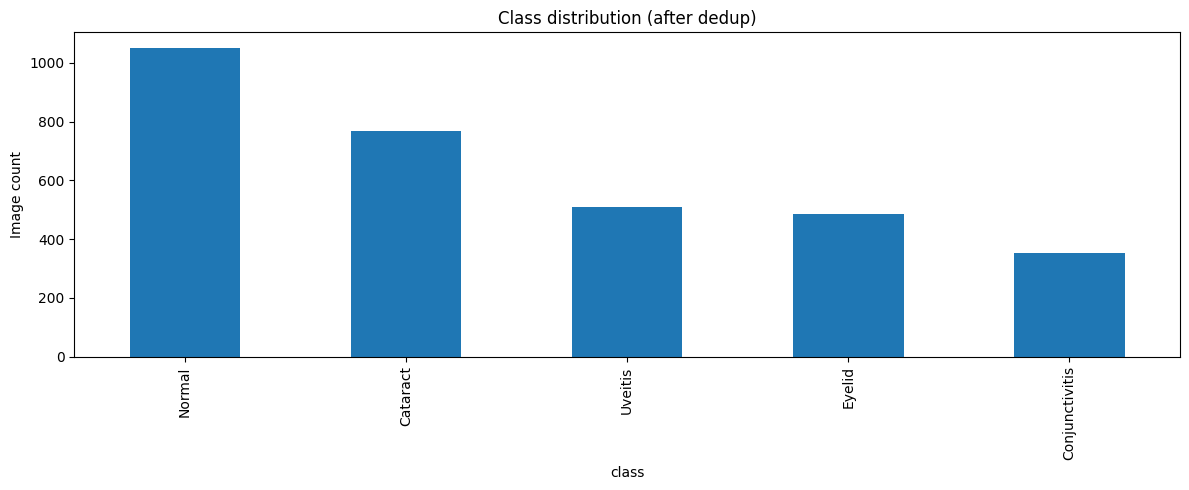

class
Normal            1051
Cataract           768
Uveitis            508
Eyelid             485
Conjunctivitis     352
Name: count, dtype: int64

Imbalance ratio (largest / smallest): 3.0


In [11]:
# Step 9 — Class Balance Check: plots per-class counts on the deduplicated data and computes the imbalance ratio
import matplotlib.pyplot as plt

class_counts = image_df_dedup['class'].value_counts()
plt.figure(figsize=(12, 5))
class_counts.plot(kind='bar')
plt.ylabel('Image count')
plt.title('Class distribution (after dedup)')
plt.tight_layout()
plt.show()

print(class_counts)
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (largest / smallest): {imbalance_ratio:.1f}")
if imbalance_ratio > 3:
    print("=> Significant imbalance. Use class_weight, and/or oversample the smallest classes.")

In [12]:
# Step 10 — Class Weights: computes balanced class weights via sklearn for use during training
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = sorted(image_df_dedup['class'].unique())
labels = image_df_dedup['class'].values

weights = compute_class_weight(class_weight='balanced', classes=np.array(classes), y=labels)
class_weight_dict = {c: w for c, w in zip(classes, weights)}
print("Class weights:")
for c, w in sorted(class_weight_dict.items(), key=lambda x: -x[1]):
    print(f"  {c:<25} {w:.3f}")

Class weights:
  Conjunctivitis            1.798
  Eyelid                    1.305
  Uveitis                   1.246
  Cataract                  0.824
  Normal                    0.602


In [13]:
# Step 11 — Final Export: saves the clean deduplicated dataset, the duplicates log, and the cross-class collision log
image_df_dedup.to_csv('/kaggle/working/mobile_eye_disease_clean_dedup.csv', index=False)
duplicates_removed_df.to_csv('/kaggle/working/mobile_eye_disease_duplicates_removed.csv', index=False)

if colliding_groups:
    import json as _json
    with open('/kaggle/working/mobile_eye_disease_class_collisions.json', 'w') as f:
        _json.dump([{'file_paths': c['file_paths'], 'classes': list(c['classes'])} for c in colliding_groups], f, indent=2)

print("Clean dataset exported:", image_df_dedup.shape)
print("Duplicates log exported:", duplicates_removed_df.shape)
print("Class collisions logged:", len(colliding_groups))

assert image_df_dedup['file_path'].is_unique, "Duplicate file_path still present"
assert image_df_dedup['class'].isna().sum() == 0, "Unlabeled images present"
print("All assertions passed")

Clean dataset exported: (3164, 9)
Duplicates log exported: (854, 9)
Class collisions logged: 5
All assertions passed


In [14]:
# Step 12 — Final Summary: prints the final total image count after preprocessing
print("Final total images in cleaned dataset:", image_df_dedup.shape[0])
print(image_df_dedup['class'].value_counts())

Final total images in cleaned dataset: 3164
class
Normal            1051
Cataract           768
Uveitis            508
Eyelid             485
Conjunctivitis     352
Name: count, dtype: int64
